# Which Plan Is the Best?

The company offers customers two prepaid plans: Surf and Ultimate. The commercial department wants to know which plan generates more revenue in order to adjust the advertising budget.

You will perform a preliminary analysis of the plans based on a small sample of customers. You will have data from 500 Megaline customers: who they are, where they are from, which plan they use, and the number of calls and messages made in 2018. Your job is to analyze customer behavior and determine which prepaid plan generates more revenue.

## Initialization

In [1]:
# Loading all libraries
import pandas as pd
from scipy import stats as st
import numpy as np
from matplotlib import pyplot as plt


## Load the Data

In [2]:
# Load the data files into different DataFrames
df_calls = pd.read_csv('datasets/megaline_calls.csv')
df_internet = pd.read_csv('datasets/megaline_internet.csv')
df_messages = pd.read_csv('datasets/megaline_messages.csv')
df_plans = pd.read_csv('datasets/megaline_plans.csv')
df_users = pd.read_csv('datasets/megaline_users.csv')

## Prepare the Data

### Plans

In [3]:
# Printing general information/summary about the plans DataFrame
print(df_plans.info())

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      str    
dtypes: float64(2), int64(5), str(1)
memory usage: 260.0 bytes
None


In [4]:
# Printing a sample of the plans data
print(df_plans.head())


   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


df_plans is a simple, consistent table that presents the characteristics of the available plans and does not need any adjustments.
Its characteristics are:

* contains 8 columns and 2 rows
* there are no explicitly null or missing values
* there are no duplicate values
* the header contains consistent names and does not need correction
* the variable types appear appropriate for the values they represent

### Users

In [5]:
# Printing general information/summary about the users DataFrame
print(df_users.info())


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     500 non-null    int64
 1   first_name  500 non-null    str  
 2   last_name   500 non-null    str  
 3   age         500 non-null    int64
 4   city        500 non-null    str  
 5   reg_date    500 non-null    str  
 6   plan        500 non-null    str  
 7   churn_date  34 non-null     str  
dtypes: int64(2), str(6)
memory usage: 31.4 KB
None


In [6]:
# Printing a sample of the users data
print(df_users.head(5))


   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

     reg_date      plan churn_date  
0  2018-12-24  ultimate        NaN  
1  2018-08-13      surf        NaN  
2  2018-10-21      surf        NaN  
3  2018-01-28      surf        NaN  
4  2018-05-23      surf        NaN  


In [7]:
# Finding non-null rows in the 'churn_date' column for evaluation
df_users_churn = df_users[~df_users['churn_date'].isna()]
print(df_users_churn.head(1))


   user_id first_name last_name  age                                    city  \
6     1006     Jesusa  Bradford   73  San Francisco-Oakland-Berkeley, CA MSA   

     reg_date      plan  churn_date  
6  2018-11-27  ultimate  2018-12-18  


###### df_users TABLE SUMMARY

df_users is a table that presents the sample of customers to be studied.
Its basic characteristics are:
* contains 8 columns and 500 rows
* the header contains consistent names and does not need correction
* apparently, there are no explicitly null values; the 'churn_date' column contains missing values, but they are within the expected context.

It requires the following interventions:
* the variable types of the 'reg_date' and 'churn_date' columns need to be adjusted to datetime in order to facilitate data manipulation
* it is necessary to investigate the presence of duplicate data

It should be improved as follows:
* the content of the 'city' column is more extensive than what it needs to convey; this column can be improved by splitting it into two parts, one with the MSA (Metropolitan Statistical Area) it belongs to and the other with the name of the cities within this metropolitan statistical area
* the 'reg_date' and 'churn_date' columns will have their dates split into day, month, and year components
* missing values will be replaced with 0

#### Fixing the Data

In [8]:
# adjusting the 'reg_date' and 'churn_date' columns to datetime
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'], format='%Y-%m-%d')
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'], format='%Y-%m-%d')

print(df_users.info())


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    str           
 2   last_name   500 non-null    str           
 3   age         500 non-null    int64         
 4   city        500 non-null    str           
 5   reg_date    500 non-null    datetime64[us]
 6   plan        500 non-null    str           
 7   churn_date  34 non-null     datetime64[us]
dtypes: datetime64[us](2), int64(2), str(4)
memory usage: 31.4 KB
None


* the 'reg_date' and 'churn_date' columns containing date content were converted to the datetime type

In [9]:
# Investigating duplicate values
print('Number of explicitly duplicated rows:', df_users.duplicated().sum())


Number of explicitly duplicated rows: 0


* no duplicate rows were found

#### Enriching the Data

In [10]:
# splitting the 'city' column into 'city_msa' and 'state_msa'
df_users[['city_msa','state_msa']] = df_users['city'].str.split(',', n=1, expand=True)

# stripping whitespace and removing the 'MSA' suffix
df_users['state_msa'] = df_users['state_msa'].str.strip()
df_users['state_msa'] = df_users['state_msa'].str.replace('MSA', '', regex=False).str.strip()

# dropping the original 'city' column
df_users = df_users.drop(columns='city')


In [11]:
# splitting the 'reg_date' and 'churn_date' columns into day, month, and year components

# working on the 'reg_date' column
df_users['reg_day'] = df_users['reg_date'].dt.day 
df_users['reg_month'] = df_users['reg_date'].dt.month 
df_users['reg_year'] = df_users['reg_date'].dt.year

df_users = df_users.drop(columns='reg_date')              # dropping the original 'reg_date' column

# working on the 'churn_date' column
df_users['churn_day'] = df_users['churn_date'].dt.day 
df_users['churn_month'] = df_users['churn_date'].dt.month 
df_users['churn_year'] = df_users['churn_date'].dt.year

df_users = df_users.drop(columns='churn_date')              # dropping the original 'churn_date' column

# printing to make sure the goal was achieved
print(df_users.head())


   user_id first_name  last_name  age      plan  \
0     1000   Anamaria      Bauer   45  ultimate   
1     1001     Mickey  Wilkerson   28      surf   
2     1002     Carlee    Hoffman   36      surf   
3     1003   Reynaldo    Jenkins   52      surf   
4     1004    Leonila   Thompson   40      surf   

                        city_msa state_msa  reg_day  reg_month  reg_year  \
0  Atlanta-Sandy Springs-Roswell        GA       24         12      2018   
1        Seattle-Tacoma-Bellevue        WA       13          8      2018   
2   Las Vegas-Henderson-Paradise        NV       21         10      2018   
3                          Tulsa        OK       28          1      2018   
4        Seattle-Tacoma-Bellevue        WA       23          5      2018   

   churn_day  churn_month  churn_year  
0        NaN          NaN         NaN  
1        NaN          NaN         NaN  
2        NaN          NaN         NaN  
3        NaN          NaN         NaN  
4        NaN          NaN         Na

In [12]:
# replacing missing values with 0
df_users['churn_day'] = df_users['churn_day'].fillna(0).astype(int)
df_users['churn_month'] = df_users['churn_month'].fillna(0).astype(int)
df_users['churn_year'] = df_users['churn_year'].fillna(0).astype(int)

print(df_users.head())


   user_id first_name  last_name  age      plan  \
0     1000   Anamaria      Bauer   45  ultimate   
1     1001     Mickey  Wilkerson   28      surf   
2     1002     Carlee    Hoffman   36      surf   
3     1003   Reynaldo    Jenkins   52      surf   
4     1004    Leonila   Thompson   40      surf   

                        city_msa state_msa  reg_day  reg_month  reg_year  \
0  Atlanta-Sandy Springs-Roswell        GA       24         12      2018   
1        Seattle-Tacoma-Bellevue        WA       13          8      2018   
2   Las Vegas-Henderson-Paradise        NV       21         10      2018   
3                          Tulsa        OK       28          1      2018   
4        Seattle-Tacoma-Bellevue        WA       23          5      2018   

   churn_day  churn_month  churn_year  
0          0            0           0  
1          0            0           0  
2          0            0           0  
3          0            0           0  
4          0            0           


* the 'city' column was split and replaced by the following columns:

- 'city_msa', which contains the explicit name of the cities within the MSA;

- 'state_msa', which contains the state of the MSA


* the date columns had their components split into day, month, and year

### Calls

In [13]:
# Printing general information/summary about the calls DataFrame
print(df_calls.info())


<class 'pandas.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  str    
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  str    
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 4.2 MB
None


In [14]:
# Printing a sample of the calls data
print(df_calls.head())


         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22


###### df_calls TABLE SUMMARY

df_calls is a table that presents the calls data.
Its basic characteristics are:
* contains 4 columns and 137,735 rows
* the header contains consistent names that do not need correction
* apparently, there are no explicitly null values
* the variable types are appropriate, except for the 'call_date' column. However, the 'duration' column will be kept under observation to assess the future need to change its data to datetime if necessary.

It requires the following interventions:
* the 'call_date' column needs to have its type changed to datetime
* it is necessary to investigate the presence of duplicate data

It should be improved as follows:
* the 'duration' column should specify the unit of measurement in minutes
* the 'call_date' column will have its date split into day, month, and year components

#### Fixing the Data

In [15]:
# adjusting the 'call_date' column to datetime
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'], format='%Y-%m-%d')

print(df_calls.info())


<class 'pandas.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  str           
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[us]
 3   duration   137735 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 4.2 MB
None


In [16]:
# Investigating duplicate values
print('Number of explicitly duplicated rows:', df_calls.duplicated().sum())


Number of explicitly duplicated rows: 0


### Enriching the Data

In [17]:
# renaming the 'duration' column to specify the unit of measurement as 'duration_minutes'
df_calls = df_calls.rename(columns={'duration': 'duration_minutes'})

print(df_calls.head())


         id  user_id  call_date  duration_minutes
0   1000_93     1000 2018-12-27              8.52
1  1000_145     1000 2018-12-27             13.66
2  1000_247     1000 2018-12-27             14.48
3  1000_309     1000 2018-12-28              5.76
4  1000_380     1000 2018-12-30              4.22


In [18]:
# splitting the 'call_date' column into day, month, and year components
df_calls['call_day'] = df_calls['call_date'].dt.day 
df_calls['call_month'] = df_calls['call_date'].dt.month 
df_calls['call_year'] = df_calls['call_date'].dt.year

df_calls = df_calls.drop(columns='call_date')              # dropping the original 'call_date' column

# printing to make sure the goal was achieved
print(df_calls.head())


         id  user_id  duration_minutes  call_day  call_month  call_year
0   1000_93     1000              8.52        27          12       2018
1  1000_145     1000             13.66        27          12       2018
2  1000_247     1000             14.48        27          12       2018
3  1000_309     1000              5.76        28          12       2018
4  1000_380     1000              4.22        30          12       2018


* the call_date column was converted to the datetime type
* the call_date column had its components split into day, month, and year 
* there are no explicitly duplicated values
* the 'duration' column header was renamed to 'duration_minutes'

### Messages

In [19]:
# Printing general information/summary about the messages DataFrame
print(df_messages.info())


<class 'pandas.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            76051 non-null  str  
 1   user_id       76051 non-null  int64
 2   message_date  76051 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.7 MB
None


In [20]:
# Printing a sample of the messages data
print(df_messages.head())


         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


##### df_messages TABLE SUMMARY

df_messages is a table that presents the text message data.
Its basic characteristics are:
* contains 3 columns and 76,051 rows
* the header contains consistent names that do not need adjustment
* apparently, there are no explicitly null values
* it is necessary to investigate the presence of duplicate data
* the variable types are appropriate, except for the 'message_date' column.

It requires the following interventions:
* the 'message_date' column needs to have its type changed to datetime
* it is necessary to investigate the presence of duplicate data

It should be improved as follows:
* the 'message_date' column will have its date split into day, month, and year components

### Fixing the Data

In [21]:
# adjusting the 'message_date' column to datetime
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'], format='%Y-%m-%d')

print(df_messages.info())


<class 'pandas.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  str           
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 1.7 MB
None


In [22]:
# Investigating duplicate values
print('Number of explicitly duplicated rows:', df_messages.duplicated().sum())


Number of explicitly duplicated rows: 0


#### Enriching the Data

In [23]:
# splitting the 'message_date' column into day, month, and year components
df_messages['message_day'] = df_messages['message_date'].dt.day 
df_messages['message_month'] = df_messages['message_date'].dt.month 
df_messages['message_year'] = df_messages['message_date'].dt.year

df_messages = df_messages.drop(columns='message_date')              # dropping the original 'message_date' column

# printing to make sure the goal was achieved
print(df_messages.head())


         id  user_id  message_day  message_month  message_year
0  1000_125     1000           27             12          2018
1  1000_160     1000           31             12          2018
2  1000_223     1000           31             12          2018
3  1000_251     1000           27             12          2018
4  1000_255     1000           26             12          2018


* the 'message_date' column was converted to the datetime type
* there are no explicitly duplicated values
* the 'message_date' column had its components split into day, month, and year

### Internet

In [24]:
# Printing general information/summary about the internet DataFrame
print(df_internet.info())


<class 'pandas.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  str    
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  str    
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 3.2 MB
None


In [25]:
# Printing a sample of the internet traffic data
print(df_internet.head())


         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22


##### df_internet TABLE SUMMARY

df_internet is a table that presents the web session data.
Its basic characteristics are:
* contains 4 columns and 104,825 rows
* the header contains consistent names that do not need adjustment
* apparently, there are no explicitly null values
* it is necessary to investigate the presence of duplicate data
* apparently, the variable types are appropriate, except for the 'session_date' column.

It requires the following interventions:
* the 'session_date' column needs to have its type changed to datetime
* it is necessary to investigate the presence of duplicate data

It should be improved as follows:
* the 'session_date' column will have its date split into day, month, and year components

### Fixing the Data

In [26]:
# adjusting the 'session_date' column to datetime
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'], format='%Y-%m-%d')

print(df_internet.info())


<class 'pandas.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  str           
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[us]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 3.2 MB
None


In [27]:
# Investigating duplicate values
print('Number of explicitly duplicated rows:', df_internet.duplicated().sum())


Number of explicitly duplicated rows: 0


### Enriching the Data

In [28]:
# splitting the 'session_date' column into day, month, and year components
df_internet['session_day'] = df_internet['session_date'].dt.day 
df_internet['session_month'] = df_internet['session_date'].dt.month 
df_internet['session_year'] = df_internet['session_date'].dt.year

df_internet = df_internet.drop(columns='session_date')              # dropping the original 'session_date' column

# printing to make sure the goal was achieved
print(df_internet.head())


         id  user_id  mb_used  session_day  session_month  session_year
0   1000_13     1000    89.86           29             12          2018
1  1000_204     1000     0.00           31             12          2018
2  1000_379     1000   660.40           28             12          2018
3  1000_413     1000   270.99           26             12          2018
4  1000_442     1000   880.22           27             12          2018


* the 'session_date' column was converted to the datetime type
* there are no explicitly duplicated values
* the 'session_date' column had its components split into day, month, and year

## Study the Plan Conditions

In [29]:
# Printing the plan conditions and making sure they make sense
print(df_plans.head())


   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


## Aggregate the Data by User

In [30]:
# Calculating the number of calls made by each user per month. Save the result.

# Aggregating the number of calls made by each user per month
agg_num_calls = {'id': 'count'}
grp_calls = df_calls.groupby(['user_id','call_month'])
grp_calls.agg(agg_num_calls)

# Saving it into a df
df_num_calls = grp_calls.agg(agg_num_calls).reset_index().rename(columns={'id':'number_calls'})

# Creating a key column to merge the dfs
df_num_calls['merge_key'] = df_num_calls['user_id'].astype(str) + '_' + df_num_calls['call_month'].astype(str)
print(df_num_calls)


      user_id  call_month  number_calls merge_key
0        1000          12            16   1000_12
1        1001           8            27    1001_8
2        1001           9            49    1001_9
3        1001          10            65   1001_10
4        1001          11            64   1001_11
...       ...         ...           ...       ...
2253     1498          12            39   1498_12
2254     1499           9            41    1499_9
2255     1499          10            53   1499_10
2256     1499          11            45   1499_11
2257     1499          12            65   1499_12

[2258 rows x 4 columns]


In [31]:
# Calculating the number of minutes used by each user per month. Save the result.

In [32]:
# Rounding up the duration of each call
df_calls['duration_minutes'] = np.ceil(df_calls['duration_minutes'])

In [33]:
# Aggregating the number of minutes used by each user per month
agg_minutes = {'duration_minutes': 'sum'}
grp_calls = df_calls.groupby(['user_id','call_month'])
minutes_calls = grp_calls.agg(agg_minutes)

# Saving it into a df
df_minutes_calls = grp_calls.agg(agg_minutes).reset_index().rename(columns={'duration_minutes':'sum_duration_minutes'})

# Creating a key column to merge the dfs
df_minutes_calls['merge_key'] = df_minutes_calls['user_id'].astype(str) + '_' + df_minutes_calls['call_month'].astype(str)
print(df_minutes_calls)


      user_id  call_month  sum_duration_minutes merge_key
0        1000          12                 124.0   1000_12
1        1001           8                 182.0    1001_8
2        1001           9                 315.0    1001_9
3        1001          10                 393.0   1001_10
4        1001          11                 426.0   1001_11
...       ...         ...                   ...       ...
2253     1498          12                 339.0   1498_12
2254     1499           9                 346.0    1499_9
2255     1499          10                 385.0   1499_10
2256     1499          11                 308.0   1499_11
2257     1499          12                 496.0   1499_12

[2258 rows x 4 columns]


In [34]:
# Calculating the number of messages sent by each user per month.

# Aggregating the number of messages sent by each user per month
agg_message = {'id': 'count'}
grp_messages = df_messages.groupby(['user_id','message_month'])
number_messages = grp_messages.agg(agg_message)

# Saving it into a df
df_number_messages = grp_messages.agg(agg_message).reset_index().rename(columns={'id':'number_messages'})

# Creating a key column to merge the dfs
df_number_messages['merge_key'] = df_number_messages['user_id'].astype(str) + '_' + df_number_messages['message_month'].astype(str)
print(df_number_messages)


      user_id  message_month  number_messages merge_key
0        1000             12               11   1000_12
1        1001              8               30    1001_8
2        1001              9               44    1001_9
3        1001             10               53   1001_10
4        1001             11               36   1001_11
...       ...            ...              ...       ...
1801     1496              9               21    1496_9
1802     1496             10               18   1496_10
1803     1496             11               13   1496_11
1804     1496             12               11   1496_12
1805     1497             12               50   1497_12

[1806 rows x 4 columns]


In [35]:
# Calculating the volume of internet traffic used by each user per month. Save the result.

# Aggregating the volume of internet traffic used by each user per month
agg_internet = {'mb_used': 'sum'}
grp_internet = df_internet.groupby(['user_id','session_month'])
mbs_used = grp_internet.agg(agg_internet)

# Saving it into a df
df_mbs_used = grp_internet.agg(agg_internet).reset_index().rename(columns={'mb_used':'sum_mb_used'})

# Creating a key column to merge the dfs
df_mbs_used['merge_key'] = df_mbs_used['user_id'].astype(str) + '_' + df_mbs_used['session_month'].astype(str)
print(df_mbs_used)


      user_id  session_month  sum_mb_used merge_key
0        1000             12      1901.47   1000_12
1        1001              8      6919.15    1001_8
2        1001              9     13314.82    1001_9
3        1001             10     22330.49   1001_10
4        1001             11     18504.30   1001_11
...       ...            ...          ...       ...
2272     1498             12     23137.69   1498_12
2273     1499              9     12984.76    1499_9
2274     1499             10     19492.43   1499_10
2275     1499             11     16813.83   1499_11
2276     1499             12     22059.21   1499_12

[2277 rows x 4 columns]


In [36]:
# Joining the calls, minutes, messages, and internet data based on user_id and month

# Joining the df with call and minute data
df_num_min = df_num_calls.merge(df_minutes_calls, on='merge_key', how='outer')
df_num_min = df_num_min.drop(columns=['user_id_x', 'user_id_y', 'call_month_x', 'call_month_y'])     # adjusting the columns
#print(df_num_min)

# Joining the df with call, minute, and message data
df_num_min_mess = df_num_min.merge(df_number_messages, on='merge_key', how='outer')
df_num_min_mess = df_num_min_mess.drop(columns=['user_id', 'message_month'])                         
#print(df_num_min_mess)

# Joining the df with call, minute, message, and internet data
df_user_month = df_num_min_mess.merge(df_mbs_used, on='merge_key', how='outer')

# Adjusting the number, type, and order of the columns
df_user_month[['user_id','month_used']] = df_user_month['merge_key'].str.split('_', n=1, expand=True)
df_user_month = df_user_month.drop(columns=['session_month', 'merge_key'])
df_user_month['user_id'] = df_user_month['user_id'].astype(int)
df_user_month = df_user_month.sort_values('user_id')
df_user_month = df_user_month[['user_id', 'month_used', 'number_calls', 'sum_duration_minutes', 'number_messages', 'sum_mb_used']]

# Replacing missing values
df_user_month['number_calls'] = df_user_month['number_calls'].fillna(0).astype(int)
df_user_month['sum_duration_minutes'] = df_user_month['sum_duration_minutes'].fillna(0)
df_user_month['number_messages'] = df_user_month['number_messages'].fillna(0).astype(int)
df_user_month['sum_mb_used'] = df_user_month['sum_mb_used'].fillna(0)

print(df_user_month.tail(20))


      user_id month_used  number_calls  sum_duration_minutes  number_messages  \
2273     1496         11            39                 308.0               13   
2274     1496         12            40                 294.0               11   
2275     1496          8            18                 122.0                2   
2276     1496          9            52                 414.0               21   
2277     1497         12            54                 300.0               50   
2278     1498         10            46                 298.0                0   
2279     1498         11            41                 223.0                0   
2280     1498         12            39                 339.0                0   
2281     1498          2            37                 244.0                0   
2282     1498          3            37                 266.0                0   
2283     1498          4            47                 365.0                0   
2284     1498          5    

In [37]:
# Adding the plan information
# creating a condensed users df
df_users_fit = df_users[['user_id', 'plan', 'reg_month', 'churn_month']]

print(df_users_fit.tail())


     user_id      plan  reg_month  churn_month
495     1495      surf          9            0
496     1496      surf          2            0
497     1497  ultimate         12            0
498     1498      surf          2            0
499     1499      surf          5            0

In [38]:
# Creating a df with each user's plan
df_users_plan = df_users_fit.merge(df_plans, 
                                   left_on='plan',
                                   right_on='plan_name').drop(columns='plan_name')


In [39]:

# Creating a df with the monthly consumption data and the charge for each item
df_month_plan_used = df_user_month.merge(df_users_plan, on='user_id', how='outer')

# dropping rows with missing values

In [40]:
df_month_plan_used = df_month_plan_used.dropna(subset=['month_used'])

In [41]:
# Creating a new column to calculate the extra cost for exceeded messages
df_month_plan_used['usd_message_add'] = (
    (df_month_plan_used['number_messages']
     -df_month_plan_used['messages_included']).clip(lower=0) 
    * df_month_plan_used['usd_per_message']
)


In [42]:
# Creating a new column to calculate the extra cost for exceeded minutes
df_month_plan_used['usd_minute_add'] = (
    (df_month_plan_used['sum_duration_minutes']
     -df_month_plan_used['minutes_included']).clip(lower=0) 
    * df_month_plan_used['usd_per_minute']
)


Converting the overage to gigabytes and rounding up before multiplying by the price

In [43]:
# Creating a column with the overage amount
df_month_plan_used['overage_mb'] = (
    df_month_plan_used['sum_mb_used'] - df_month_plan_used['mb_per_month_included']
).clip(lower=0)

# Rounding the overage up
df_month_plan_used['overage_gb'] = np.ceil(df_month_plan_used['overage_mb'] / 1024)


In [44]:
# Creating a new column to calculate the extra cost for exceeded internet usage

# Calculating exclusively the cost of the internet usage overage
df_month_plan_used['usd_mb_add'] = (
    df_month_plan_used['overage_gb'] * df_month_plan_used['usd_per_gb'])


In [45]:
# Calculating the monthly revenue for each user
df_month_plan_used['monthly_revenue'] = (
    df_month_plan_used['usd_monthly_pay'] 
    + df_month_plan_used['usd_message_add'] 
    + df_month_plan_used['usd_minute_add'] 
    + df_month_plan_used['usd_mb_add']
).round(2)

print(df_month_plan_used.head())


   user_id month_used  number_calls  sum_duration_minutes  number_messages  \
0     1000         12          16.0                 124.0             11.0   
1     1001         10          65.0                 393.0             53.0   
2     1001         11          64.0                 426.0             36.0   
3     1001         12          56.0                 412.0             44.0   
4     1001          8          27.0                 182.0             30.0   

   sum_mb_used      plan  reg_month  churn_month  messages_included  ...  \
0      1901.47  ultimate         12            0               1000  ...   
1     22330.49      surf          8            0                 50  ...   
2     18504.30      surf          8            0                 50  ...   
3     19369.18      surf          8            0                 50  ...   
4      6919.15      surf          8            0                 50  ...   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  \
0      

## Study User Behavior

### Calls

In [46]:
# Adding the plan column to df_calls for each user

df_calls_plan = (df_calls.merge(df_users_fit[['user_id', 'plan']], 
                                         on='user_id', how='left').
                drop(columns=['call_year', 'call_day']))

print(df_calls_plan)


              id  user_id  duration_minutes  call_month      plan
0        1000_93     1000               9.0          12  ultimate
1       1000_145     1000              14.0          12  ultimate
2       1000_247     1000              15.0          12  ultimate
3       1000_309     1000               6.0          12  ultimate
4       1000_380     1000               5.0          12  ultimate
...          ...      ...               ...         ...       ...
137730  1499_199     1499               9.0          11      surf
137731  1499_200     1499              11.0          10      surf
137732  1499_201     1499               9.0           9      surf
137733  1499_202     1499               1.0          10      surf
137734  1499_203     1499              14.0          12      surf

[137735 rows x 5 columns]


AVERAGE CALL DURATION PER MONTH PER PLAN 
     call_month      surf  ultimate
0            1  6.766667  6.910714
1            2  7.303279  6.916667
2            3  7.106742  6.614130
3            4  7.191899  7.088176
4            5  7.173700  7.054491
5            6  7.251863  7.110522
6            7  7.124836  7.276061
7            8  7.124718  7.015709
8            9  7.128537  7.166857
9           10  7.120604  7.066706
10          11  7.160421  7.138889
11          12  7.239358  7.073878


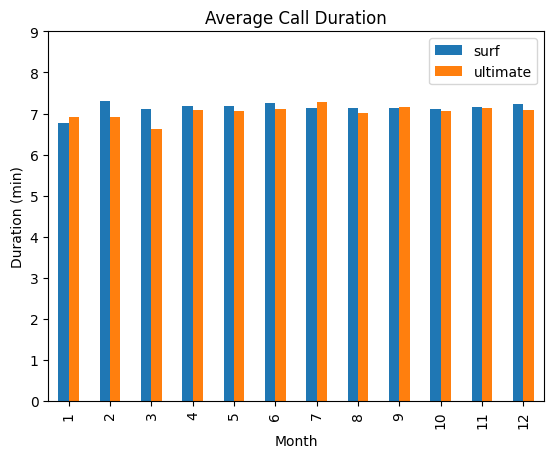

In [47]:
# Comparing the average call duration for each plan, for each month. 
# Create a bar chart to visualize the result.

# Creating a table that compares the average call duration for each plan, for each month
df_mean_calls = (df_calls_plan.pivot_table(index='call_month',
                                 columns='plan',
                                 values='duration_minutes',
                                 aggfunc='mean')
                                .reset_index()
                                .rename_axis(columns=None))

print('AVERAGE CALL DURATION PER MONTH PER PLAN \n', df_mean_calls)

# Creating a chart
df_mean_calls.plot(x='call_month', kind='bar',
                  title='Average Call Duration',
                  xlabel='Month', ylabel='Duration (min)',
                  ylim=[0,9])

plt.show()


MINUTES USED PER USER PER MONTH
    user_id month_used  min_user_month      plan
0     1000         12           124.0  ultimate
1     1001         10           393.0      surf
2     1001         11           426.0      surf
3     1001         12           412.0      surf
4     1001          8           182.0      surf


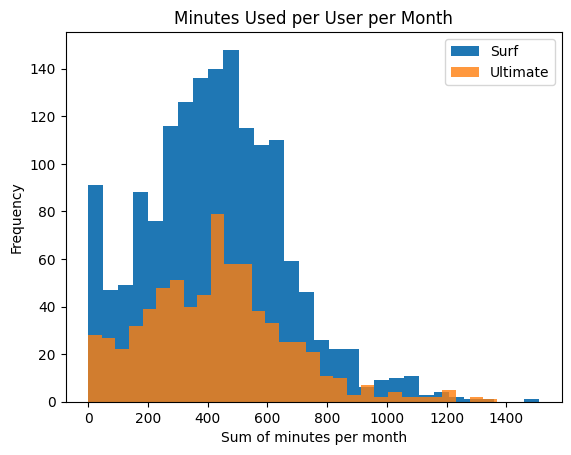

In [48]:
# Compare the number of minutes users of each plan require per month. 
# Build a histogram.

# Creating a df with the sum of minutes/month used per user
df_minute_month_plan = (df_month_plan_used[['user_id', 'month_used','sum_duration_minutes', 'plan']].
                    rename(columns={'sum_duration_minutes': 'min_user_month'})
                       )
print('MINUTES USED PER USER PER MONTH\n', df_minute_month_plan.head())

# Building the histogram
## Surf plan histogram
df_minute_month_plan[df_minute_month_plan['plan'] == 'surf']['min_user_month'].plot(kind='hist', bins=30)

## Ultimate plan histogram
df_minute_month_plan[df_minute_month_plan['plan'] == 'ultimate']['min_user_month'].plot(kind='hist', bins=30, alpha=0.8)

## Chart details
plt.title('Minutes Used per User per Month')
plt.xlabel('Sum of minutes per month')
plt.ylabel('Frequency')
plt.legend(['Surf', 'Ultimate'])
plt.show()

In [49]:
# Calculate the mean and variance of the monthly call duration
print('Call duration calculation:\n')

# Calculation for the Surf plan
calls_surf = df_calls_plan[df_calls_plan['plan'] == 'surf']['duration_minutes']
mean_surf = calls_surf.mean().round(2)
print('The mean call duration for the Surf plan is', mean_surf)
var_surf = np.var(calls_surf).round(2)
print('The variance for the call duration on the Surf plan is', var_surf)
cv_surf = calls_surf.std() / calls_surf.mean() * 100
print(f'The Coefficient of Variation for the call duration on the Surf plan is {cv_surf:.2f}%')

# Calculation for the Ultimate plan
calls_ultimate = df_calls_plan[df_calls_plan['plan'] == 'ultimate']['duration_minutes']
mean_ultimate = calls_ultimate.mean().round(2)
print('\nThe mean call duration for the Ultimate plan is', mean_ultimate)
var_ultimate = np.var(calls_ultimate).round(2)
print('The variance for the call duration on the Ultimate plan is', var_ultimate)
cv_ultimate = calls_ultimate.std() / calls_ultimate.mean() * 100
print(f'The Coefficient of Variation for the call duration on the Ultimate plan is {cv_ultimate:.2f}%')


Call duration calculation:

The mean call duration for the Surf plan is 7.17
The variance for the call duration on the Surf plan is 35.5
The Coefficient of Variation for the call duration on the Surf plan is 83.12%

The mean call duration for the Ultimate plan is 7.1
The variance for the call duration on the Ultimate plan is 35.33
The Coefficient of Variation for the call duration on the Ultimate plan is 83.72%


/tmp/ipykernel_91/4100924950.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([calls_surf.dropna(),


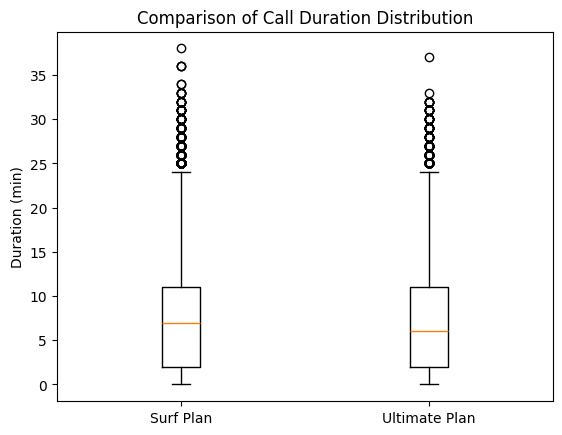

In [50]:
# Build a box plot to visualize the distribution of monthly call duration
plt.boxplot([calls_surf.dropna(), 
             calls_ultimate.dropna()], 
            labels=['Surf Plan', 'Ultimate Plan'])
plt.ylabel('Duration (min)')
plt.title('Comparison of Call Duration Distribution')
plt.show()


* the average call duration is very similar for both plans, regardless of which month of 2018 is being evaluated.
* Although the Surf plan has a larger user base than the Ultimate plan, the distribution of total minutes per month is quite similar, and the highest frequency is around 400 minutes for both plans. 
* there is little difference between the mean, variance, and coefficient of variation for call duration when comparing the Surf and Ultimate plans
* Although the variance is low in absolute terms for both plans, the coefficient of variation is greater than 30%, which indicates high dispersion in the sample, with very heterogeneous and unstable data, as confirmed by the box plot.

### Messages

MESSAGES USED PER USER PER MONTH
    user_id month_used  number_messages      plan
0     1000         12             11.0  ultimate
1     1001         10             53.0      surf
2     1001         11             36.0      surf
3     1001         12             44.0      surf
4     1001          8             30.0      surf



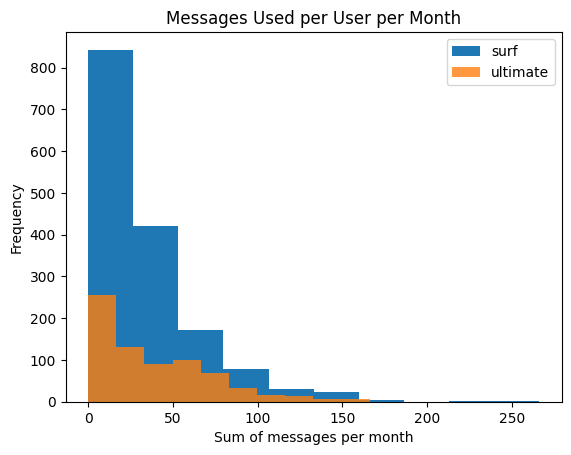

In [51]:
# Compare the number of messages users of each plan typically send per month

# Creating a df to evaluate message consumption exclusively  
df_sms_month = df_month_plan_used[['user_id', 'month_used', 'number_messages', 'plan']]

print('MESSAGES USED PER USER PER MONTH\n', df_sms_month.head().head())
print()

# Building the histogram
## Surf plan histogram
df_sms_month[df_sms_month['plan'] == 'surf']['number_messages'].plot(kind='hist', bins=10)

## Ultimate plan histogram
df_sms_month[df_sms_month['plan'] == 'ultimate']['number_messages'].plot(kind='hist', bins=10, alpha=0.8)

## Chart details
plt.title('Messages Used per User per Month')
plt.xlabel('Sum of messages per month')
plt.ylabel('Frequency')
plt.legend(['surf', 'ultimate'])
plt.show()


In [52]:
#Calculating the mean and variance of the number of messages sent per month

print('Calculation for the number of messages sent per month:')

# Calculation for the Surf plan
sms_surf = df_sms_month[df_sms_month['plan'] == 'surf']['number_messages']

mean_sms_surf = sms_surf.mean().round(2)
print('The average number of messages sent per month for the Surf plan is', mean_sms_surf)
var_sms_surf = np.var(sms_surf).round(2)
print('The variance for the number of messages sent on the Surf plan is', var_sms_surf)
cv_sms_surf = sms_surf.std() / sms_surf.mean() * 100
print(f'The Coefficient of Variation for the number of messages sent per month on the Surf plan is {cv_sms_surf:.2f}%')

# Calculation for the Ultimate plan
sms_ultimate = df_sms_month[df_sms_month['plan'] == 'ultimate']['number_messages']

mean_sms_ultimate = sms_ultimate.mean().round(2)
print('\nThe average number of messages sent per month for the Ultimate plan is', mean_sms_ultimate)
var_sms_ultimate = np.var(sms_ultimate).round(2)
print('The variance for the number of messages sent on the Ultimate plan is', var_sms_ultimate)
cv_sms_ultimate = sms_ultimate.std() / sms_ultimate.mean() * 100
print(f'The Coefficient of Variation for the number of messages sent per month on the Ultimate plan is {cv_sms_ultimate:.2f}%')

Calculation for the number of messages sent per month:
The average number of messages sent per month for the Surf plan is 31.16
The variance for the number of messages sent on the Surf plan is 1126.01
The Coefficient of Variation for the number of messages sent per month on the Surf plan is 107.73%

The average number of messages sent per month for the Ultimate plan is 37.55
The variance for the number of messages sent on the Ultimate plan is 1207.08
The Coefficient of Variation for the number of messages sent per month on the Ultimate plan is 92.59%


/tmp/ipykernel_91/3622641919.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([sms_surf.dropna(),


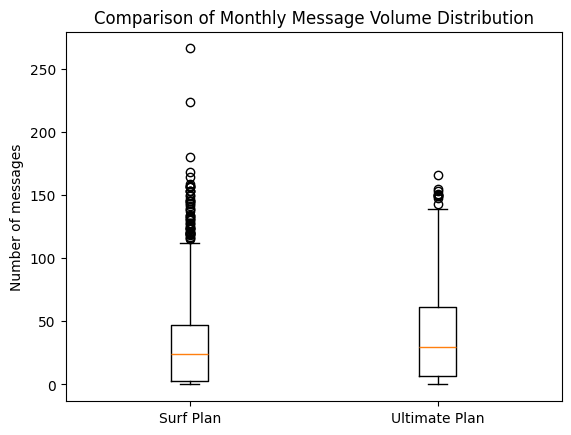

In [53]:
# Building a box plot to visualize the distribution of message counts
plt.boxplot([sms_surf.dropna(), 
             sms_ultimate.dropna()], 
labels=['Surf Plan', 'Ultimate Plan'])
plt.ylabel('Number of messages')
plt.title('Comparison of Monthly Message Volume Distribution')
plt.show()

* Although the Surf plan has a larger user base than the Ultimate plan, the distribution of messages sent per month is quite similar, and the highest frequency is below 25 messages for both plans.
* There is little difference between the mean and variance of messages sent per month when comparing the Surf and Ultimate plans.
* Evaluating the variance for both plans, in addition to having a high absolute value, the coefficient of variation is greater than 30%, which indicates high dispersion in the sample, with very heterogeneous and unstable data.
* Considering that the Surf plan includes only 50 messages, there is a certain number of users on this plan who are exceeding that amount and paying extra for it. This could be an approach for the marketing team to suggest a plan upgrade to these customers.
* No Ultimate plan customer reached even 25% of the 1,000 messages included in that plan

### Internet

INTERNET USED PER USER PER MONTH
    user_id month_used  sum_mb_used      plan
0     1000         12      1901.47  ultimate
1     1001         10     22330.49      surf
2     1001         11     18504.30      surf
3     1001         12     19369.18      surf
4     1001          8      6919.15      surf



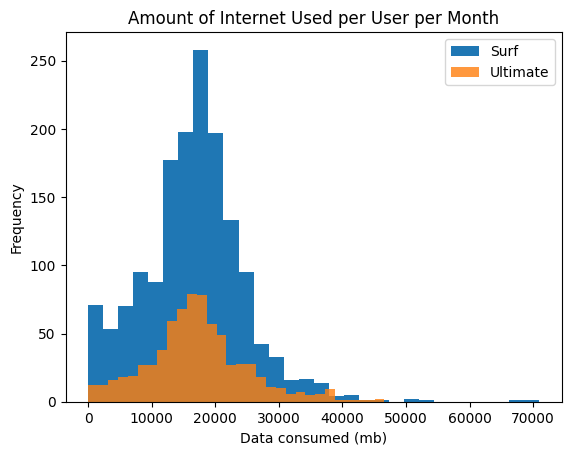

In [54]:
# Compare the amount of internet traffic consumed by users per month and per plan
# Creating a df to evaluate internet consumption exclusively  
df_mb_month = df_month_plan_used[['user_id', 'month_used', 'sum_mb_used', 'plan']]

print('INTERNET USED PER USER PER MONTH\n', df_mb_month.head())
print()

# Building the histogram
## Surf plan histogram
df_mb_month[df_mb_month['plan'] == 'surf']['sum_mb_used'].plot(kind='hist', bins=30)

## Ultimate plan histogram
df_mb_month[df_mb_month['plan'] == 'ultimate']['sum_mb_used'].plot(kind='hist', bins=30, alpha=0.8)

## Chart details
plt.title('Amount of Internet Used per User per Month')
plt.xlabel('Data consumed (mb)')
plt.ylabel('Frequency')
plt.legend(['Surf', 'Ultimate'])
plt.show()

In [55]:
# Calculating the mean and variance of monthly data consumption

print('Calculation for the amount of data consumed per month:\n')

# Calculation for the Surf plan
mb_surf = df_mb_month[df_mb_month['plan'] == 'surf']['sum_mb_used']

mean_mb_surf = mb_surf.mean().round(2)
print('The average data consumed per month for Surf plan customers is', mean_mb_surf, 'mb')
var_mb_surf = np.var(mb_surf).round(2)
print('The variance for the amount of data consumed per month by Surf plan customers is', var_mb_surf, 'mb')
cv_mb_surf = mb_surf.std() / mb_surf.mean() * 100
print(f'The Coefficient of Variation for the monthly data consumption on the Surf plan is {cv_mb_surf:.2f}%')

# Calculation for the Ultimate plan
mb_ultimate = df_mb_month[df_mb_month['plan'] == 'ultimate']['sum_mb_used']

mean_mb_ultimate = mb_ultimate.mean().round(2)
print('\nThe average data consumed per month for Ultimate plan customers is', mean_mb_ultimate, 'mb')
var_mb_ultimate = np.var(mb_ultimate).round(2)
print('The variance for the amount of data consumed per month by Ultimate plan customers is', var_mb_ultimate, 'mb')
cv_mb_ultimate = mb_ultimate.std() / mb_ultimate.mean() * 100
print(f'The Coefficient of Variation for the monthly data consumption on the Ultimate plan is {cv_mb_ultimate:.2f}%')


Calculation for the amount of data consumed per month:

The average data consumed per month for Surf plan customers is 16558.28 mb
The variance for the amount of data consumed per month by Surf plan customers is 64175571.68 mb
The Coefficient of Variation for the monthly data consumption on the Surf plan is 48.40%

The average data consumed per month for Ultimate plan customers is 17214.7 mb
The variance for the amount of data consumed per month by Ultimate plan customers is 61566665.14 mb
The Coefficient of Variation for the monthly data consumption on the Ultimate plan is 45.61%


/tmp/ipykernel_91/168935718.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([mb_surf.dropna(),


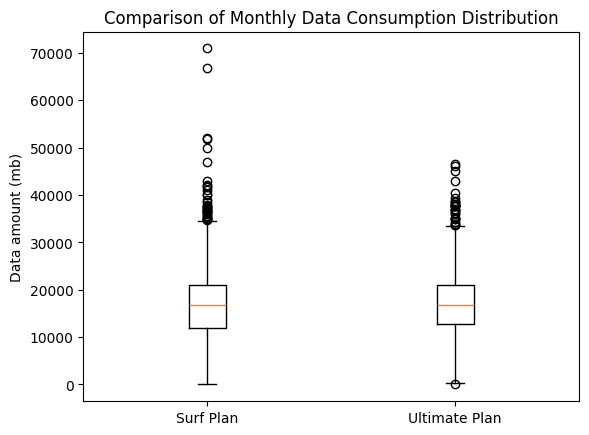

In [56]:
# Building a box plot to visualize the distribution of monthly data consumption
plt.boxplot([mb_surf.dropna(), 
             mb_ultimate.dropna()], 
            labels=['Surf Plan', 'Ultimate Plan'])
plt.ylabel('Data amount (mb)')
plt.title('Comparison of Monthly Data Consumption Distribution')
plt.show()

* Although the Surf plan has a larger user base than the Ultimate plan, the distribution of internet usage per month is quite similar, with the highest frequency at approximately 20,000mb for both plans.
* It is worth noting that the amount of internet included in the Surf plan is only 15,000mb, so a segment of users on this plan is worth studying, as they are exceeding the data included in this plan.
* There is little difference between the mean and variance of internet usage per month when comparing the Surf and Ultimate plans.
* When evaluating the variance alone for both plans, in addition to having a high absolute value, it is more than 357 times greater than the mean.
* Because the coefficient of variation is greater than 30%, this can be considered a very wide spread of the data and high dispersion in the sample, with very heterogeneous and unstable data.

## Revenue

In [57]:
# Compare basic statistics for actual monthly consumption by plan
plan_revenue_stats = df_month_plan_used.groupby('plan')['monthly_revenue'].describe()
surf_mean = plan_revenue_stats.loc['surf', 'mean'].round(2)
ultimate_mean = plan_revenue_stats.loc['ultimate', 'mean'].round(2)
surf_qt2 = plan_revenue_stats.loc['surf', '50%']
surf_max = plan_revenue_stats.loc['surf', 'max']
ultimate_qt3 = plan_revenue_stats.loc['ultimate', '75%']

print(plan_revenue_stats)
print()
print(f'The average revenue for the Surf plan is {surf_mean} usd\n')
print(f'Half of the Surf plan months fall below {surf_qt2} usd\n')
print(f'The Surf plan average of {surf_mean} is driven up by a minority of very high-consumption months — the maximum reaches {surf_max} dollars.\n')
print(f'The average revenue for the Ultimate plan is {ultimate_mean} usd\n')
print(f'For at least 75% of Ultimate plan users, the monthly consumption value was just the base package of {ultimate_qt3} usd\n')


           count       mean        std   min   25%    50%    75%     max
plan                                                                    
surf      1573.0  60.706408  55.388042  20.0  20.0  40.36  80.36  590.37
ultimate   720.0  72.313889  11.395108  70.0  70.0  70.00  70.00  182.00



The average revenue for the Surf plan is 60.71 usd

Half of the Surf plan months fall below 40.36 usd

The Surf plan average of 60.71 is driven up by a minority of very high-consumption months — the maximum reaches 590.37 dollars.

The average revenue for the Ultimate plan is 72.31 usd

For at least 75% of Ultimate plan users, the monthly consumption value was just the base package of 70.0 usd



AVERAGE REVENUE PER MONTH PER PLAN 
    month_used       surf   ultimate
0           1  20.000000  70.000000
1          10  65.421224  72.311321
2          11  58.004276  71.708661
3          12  70.557044  73.291391
4           2  34.396667  70.000000
5           3  45.941304  74.666667
6           4  40.710600  73.000000
7           5  47.628182  70.724138
8           6  49.276289  71.638298
9           7  62.674050  71.898305
10          8  63.931173  72.859155
11          9  58.271495  72.034884



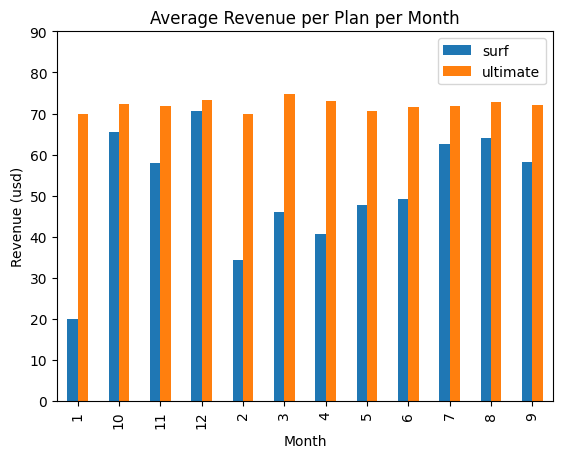

In [58]:
# Compare the average revenue of each plan for each month. 
# Create a bar chart to visualize the result

# Creating a table that compares the average revenue of each plan for each month

mean_revenue = (df_month_plan_used.pivot_table(index='month_used', 
                                               columns='plan',
                                               values='monthly_revenue',
                                               aggfunc='mean').
    reset_index().
    rename_axis(columns=None)
    )


print('AVERAGE REVENUE PER MONTH PER PLAN \n', mean_revenue)
print()

# Creating a chart
mean_revenue.plot(x='month_used', kind='bar',
                  title='Average Revenue per Plan per Month',
                  xlabel='Month', ylabel='Revenue (usd)', ylim=[0,90])

plt.show()

In [59]:
# Calculating which plan generates more revenue
revenue_plan = (df_month_plan_used.groupby('plan')['monthly_revenue'].
    sum().
    reset_index())

print('TOTAL REVENUE BY PLAN\n', revenue_plan)

TOTAL REVENUE BY PLAN
        plan  monthly_revenue
0      surf         95491.18
1  ultimate         52066.00


In [60]:
# Calculating the variance and coefficient of variation of actual monthly revenue

print('Calculation for actual monthly revenue:\n')

# Calculation for the Surf plan
revenue_surf = df_month_plan_used[df_month_plan_used['plan'] == 'surf']['monthly_revenue']

var_revenue_surf = np.var(revenue_surf).round(2)
print('The variance for monthly revenue for Surf plan customers is', var_revenue_surf)
cv_revenue_surf = revenue_surf.std() / revenue_surf.mean() * 100
print(f'The Coefficient of Variation for monthly revenue on the Surf plan is {cv_revenue_surf:.2f}%')

# Calculation for the Ultimate plan
revenue_ultimate = df_month_plan_used[df_month_plan_used['plan'] == 'ultimate']['monthly_revenue']

var_revenue_ultimate = np.var(revenue_ultimate).round(2)
print('\nThe variance for monthly revenue for Ultimate plan customers is', var_revenue_ultimate)
cv_revenue_ultimate = revenue_ultimate.std() / revenue_ultimate.mean() * 100
print(f'The Coefficient of Variation for monthly revenue on the Ultimate plan is {cv_revenue_ultimate:.2f}%')


Calculation for actual monthly revenue:



The variance for monthly revenue for Surf plan customers is 3065.88
The Coefficient of Variation for monthly revenue on the Surf plan is 91.24%

The variance for monthly revenue for Ultimate plan customers is 129.67
The Coefficient of Variation for monthly revenue on the Ultimate plan is 15.76%


/tmp/ipykernel_91/3566685055.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([revenue_surf.dropna(),


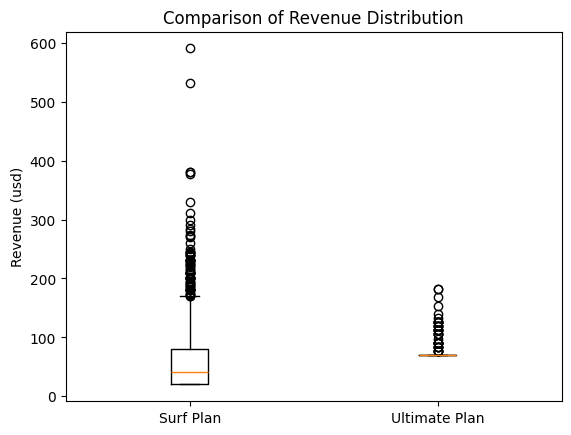

In [61]:
# Build a box plot to visualize the distribution of monthly revenue
plt.boxplot([revenue_surf.dropna(),
             revenue_ultimate.dropna()], 
            labels=['Surf Plan', 'Ultimate Plan'])
plt.ylabel('Revenue (usd)')
plt.title('Comparison of Revenue Distribution')
plt.show()


In [62]:
print(f'The average revenue for the Surf plan is {surf_mean} usd\n')
print(f'Half of the Surf plan months fall below {surf_qt2} usd\n')
print(f'The Surf plan average of {surf_mean} is driven up by a minority of very high-consumption months — the maximum reaches {surf_max} dollars.\n')
print(f'The average revenue for the Ultimate plan is {ultimate_mean} usd\n')
print(f'For at least 75% of Ultimate plan users, the monthly consumption value was just the base package of {ultimate_qt3} usd\n')


The average revenue for the Surf plan is 60.71 usd

Half of the Surf plan months fall below 40.36 usd

The Surf plan average of 60.71 is driven up by a minority of very high-consumption months — the maximum reaches 590.37 dollars.

The average revenue for the Ultimate plan is 72.31 usd

For at least 75% of Ultimate plan users, the monthly consumption value was just the base package of 70.0 usd



* Based on the mean and median shown by the data, it can be understood that Surf plan revenue does not come from all users spending a little more, but rather from some users spending a lot more.
* Ultimate plan users consume very little beyond their contracted package
* Surf plan users, in most months, consume more than double the base $20 package.
* When evaluating the variance for both plans, the absolute value is high. However, the coefficient of variation for the Surf plan is greater than 30%, which indicates high dispersion in the sample, with very heterogeneous and unstable data. The coefficient of variation for the Ultimate plan, however, is below 15%, which indicates low dispersion in the sample, with homogeneous and highly consistent data.

## Statistical Hypothesis Testing

#### Testing the hypothesis that the average revenue of Ultimate and Surf plan users is different.

Parameters:

H0 = The average revenue of Ultimate and Surf plan users is equal.
H1 = The average revenue of Ultimate and Surf plan users is different.

The statistical test selected was scipy.stats.ttest_ind, since the goal was to test the hypothesis of the mean of two statistical populations. The 'equal_var' parameter was set to 'False', based on the assessment that the variances of the samples are different.

The alpha value used was 5%.

A two-tailed test was used, since the goal is to detect a 'difference', not whether one is greater or smaller than the other.

In [63]:
# Test the hypotheses
# Using the previously prepared samples: revenue_surf and revenue_ultimate

# Setting the parameters
alpha = 0.05                  # critical level of statistical significance

# Running the test
results = st.ttest_ind(revenue_surf, revenue_ultimate, equal_var=False)

# Extract the p-value from the results
print('p-value:', results.pvalue)

# Comparing the p-value with the threshold
if results.pvalue < alpha:
    print('We reject H0: the revenue means are statistically different')
else:
    print('We fail to reject H0: there is not enough evidence of a difference')

p-value: 3.17039054811358e-15
We reject H0: the revenue means are statistically different


#### Testing the hypothesis that the average revenue of users in the NY-NJ area differs from users in other regions.

Parameters:

H0 = The average revenue of users in the NY-NJ area and users in other regions is equal.

H1 = The average revenue of users in the NY-NJ area and users in other regions is different.

The statistical test selected was scipy.stats.ttest_ind, since the goal was to test the hypothesis of the mean of two statistical populations.

The 'equal_var' parameter was set to 'False', based on the assessment that the variances of the samples are different.

The alpha value used was 5%.

A two-tailed test was used, since the goal is to detect a 'difference', not whether one is greater or smaller than the other.

In [64]:
# Preparing the samples

# Creating a df with the revenues and the areas
users_area = (df_month_plan_used.merge(df_users[['user_id','state_msa']],
                                      on='user_id', how='left'))


In [65]:
# Testing the hypothesis

# Creating the samples
ny_nj = users_area[users_area['state_msa'] == 'NY-NJ-PA']['monthly_revenue']
other_areas = users_area[~(users_area['state_msa'] == 'NY-NJ-PA')]['monthly_revenue']

# Setting the parameters
alpha = 0.05                  # critical level of statistical significance

# Running the tests
results = st.ttest_ind(ny_nj, other_areas, equal_var=False)

# Extract the p-value from the results
print('p-value:', results.pvalue)

# comparing the p-value with the threshold
if results.pvalue < alpha:
    print('We reject H0: the revenue means are statistically different')
else:
    print('We fail to reject H0: there is not enough evidence of a difference')


p-value:

 0.03352561588530014
We reject H0: the revenue means are statistically different


## General Conclusion

Looking at the accumulated revenue by plan, it is clear that the plan generating more revenue for the sample studied is the Surf plan, with $95,491.18 — nearly double the Ultimate plan's revenue of $52,066.00. The Surf plan has more than twice the number of user-months in the sample, so it generates more revenue in volume even with a lower average per user.

Evaluating the consumption behavior of the sample studied, it can be observed that the distribution of services used — whether in total minutes used, messages sent, or monthly data consumption — is quite similar, with the highest usage frequencies relatively close for both plans. Therefore, the plan that should receive more advertising investment is the Surf plan.

Comparing the data for both plans in this sample, the mean was consistently similar for the same service being evaluated, while the variance was, in most cases, large, revealing high dispersion in the sample, with very heterogeneous and unstable data, as confirmed by the box plots.

Because the revenue variances were very different between the two plans, the 'equal_var' parameter was set to False when running the statistical hypothesis tests with the scipy.stats.ttest_ind function, since Welch's version was determined to be the appropriate one.

Regarding the hypothesis test for whether the average revenue of Ultimate and Surf plan users is different, the following can be noted: the hypothesis that the average revenue of Ultimate and Surf plan users is equal was rejected, given that the p-value found was 3.1703905481135734e-15, revealing that the revenue means are statistically different.

Despite similar service consumption, customers' plan choices were different, which is reflected in a discrepant behavior when revenue is analyzed. The Surf plan's base package was $20, but the average revenue was $60.71. For the Ultimate plan, the base was $70 and the average was $72.31. This shows that, since consumption behavior is similar, Surf plan users typically needed to use additional resources that increased the amount owed by the end of the month.

Despite consuming above the plan's base package, the amount paid did not reach the value of the Ultimate plan, and because of this, customers should not feel incentivized to upgrade. It is worth evaluating, together with the commercial department, the creation of an intermediate plan to guarantee higher monthly revenue regardless of full-package consumption.

Regarding the hypothesis test for whether the average revenue of users in the NY-NJ area differs from users in other regions, the following can be noted: the hypothesis that the average revenue of NY-NJ area users and users in other regions is equal was rejected, given that the p-value found was 0.0335256158853001, revealing that the revenue means are statistically different. 

However, the p-value in this case is much closer to the 0.05 threshold than in the previous test, so the evidence here is considerably weaker, since a result of 0.033 does not carry the same strength as one of 0.000000000000003. 

Additionally, it is important to point out that each row represents one month for one user, and the same user appears multiple times; therefore, the observations are not fully independent, which is one of the test's assumptions. Furthermore, the groups being compared are very unequal in size, with the NY-NJ area representing a small fraction of the total.